## 📝 U-Net Fine-Tuning for Burned Area Segmentation
Purpose: Fine-tune a pre-trained U-Net model for semantic segmentation of multispectral satellite imagery into burned/unburned classes, using image patches from `Patch_creation` or `Merging_patches` notebooks.

## 🚀 Quick Start

- **Configure** — Set paths, experiment name, and hyperparameters in ⚙️ Configuration
- **Run All** — Runtime > Run all (cells are sequential)
- **Monitor** — Watch training output and TensorBoard for live metrics
- **Evaluate** — Review loss, accuracy, and Mean IoU (overall & per-class)


## 💡 What is Fine-Tuning?
Rather than training from scratch, this notebook adapts a model pre-trained on general image features to your specific task — burned area detection. The base model can be obtained from the `Training` notebook. Fine-tuning results in faster convergence and better performance on limited data.

# ⚙️ Configuration (set the parameters)

In [ ]:
PROJECT_DIR = "/content/drive/MyDrive/U-Net_burned_areas_project"

PATCHES_FOLDER_NAME = 'dataset_patches_PS_14_bands_excluding_blue'


model_file = 'unet_dataset_patches_PS_14_bands_excluding_blue_02_best.pt' # A model file to load
BATCH_SIZE = 8
NUM_WORKERS = 4

LR_DECODER = 1e-4
LR_ENCODER = 1e-5

EPOCHS = 30 # 30 DEFAULT
PATIENCE = 5 # Add patience for early stopping

LR = 1e-4
experiment_name = f"finetuning_{PATCHES_FOLDER_NAME}_01"

#⏳ Training (fine-tuning) of the model... (run all the cells)

In [ ]:
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd $PROJECT_DIR

/content/drive/MyDrive/Geoinformatics_Project/NewStructure


In [ ]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
from torch.nn import functional as F
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision.transforms import v2 as transforms
from torch.utils.data import TensorDataset, DataLoader, Dataset
import math
import matplotlib.gridspec as gridspec

!pip install torchview
from torchview import draw_graph

# Install torchmetrics for native metrics
!pip install -q torchmetrics
import torchmetrics
print(f"torchmetrics version: {torchmetrics.__version__}")

# Configure device and seeds
if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
else:
    device = torch.device("cpu")
# device = torch.device("cpu")

# Setup directories
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline


from pathlib import Path
import shutil
import os


torchmetrics version: 1.9.0
PyTorch version: 2.11.0+cu128
Device: cuda


In [ ]:
# Add functions for training, visualisation and model
from src.utils import (
    NPYSegmentationDataset,
    make_dataloaders,
    apply_colormap,
    plot_sample_images,
    UNetBlock,
    UNet,
    train_segmentation_model,
    plot_triptychs_from_loader,
    find_representative_indices,
    plot_triptychs_from_loader_with_selection,
    plot_layer_outputs_from_loader,
)

In [ ]:
DATASET_ROOT = f"{PROJECT_DIR}/data/merged_patches_datasets/{PATCHES_FOLDER_NAME}"
DATASET_ROOT = Path(DATASET_ROOT)

In [ ]:
LOCAL_ROOT = Path("/content/finetune_dataset")

TRAIN_IMG_DIR = LOCAL_ROOT / "train/images"
TRAIN_MASK_DIR = LOCAL_ROOT / "train/labels"

VAL_IMG_DIR = LOCAL_ROOT / "val/images"
VAL_MASK_DIR = LOCAL_ROOT / "val/labels"

In [ ]:
TEST_IMG_DIR = LOCAL_ROOT / "test/images"
TEST_MASK_DIR = LOCAL_ROOT / "test/labels"

In [ ]:
if LOCAL_ROOT.exists():
    shutil.rmtree(LOCAL_ROOT)

TRAIN_IMG_DIR.mkdir(parents=True)
TRAIN_MASK_DIR.mkdir(parents=True)

VAL_IMG_DIR.mkdir(parents=True)
VAL_MASK_DIR.mkdir(parents=True)

In [ ]:
TEST_IMG_DIR.mkdir(parents=True)
TEST_MASK_DIR.mkdir(parents=True)

In [ ]:
from tqdm import tqdm
OUT_DIR = f"/content/{PATCHES_FOLDER_NAME}"

In [ ]:
shutil.copytree(
    f"{PROJECT_DIR}/data/merged_patches_datasets/{PATCHES_FOLDER_NAME}",
    OUT_DIR,
    dirs_exist_ok=True
)

'/content/dataset_patches_PS_14_bands_excluding_blue'

In [ ]:
loaders = make_dataloaders(
    OUT_DIR,
    batch_size=16,
    num_workers=2
)

train_loader = loaders["train"]
val_loader = loaders["val"]
test_loader = loaders["test"]

train:  1600 patches →  100 batches/epoch
val  :  1165 patches →   73 batches/epoch
test :   600 patches →   38 batches/epoch


In [ ]:
print("Creating datasets...")

train_dataset = NPYSegmentationDataset(
    root        = OUT_DIR,
    split       = "train",
    augmentation = True
)

val_dataset = NPYSegmentationDataset(
    root        = OUT_DIR,
    split       = "val",
    augmentation = False
)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

Creating datasets...
Train dataset size: 1600
Validation dataset size: 1165


Load existing U-Net

In [ ]:
import json

with open(f"{OUT_DIR}/metadata.json") as f:
    meta = json.load(f)

INPUT_CHANNELS = meta["n_bands_total"]
NUM_CLASSES = meta["n_classes"]

print(f"Каналов в патче: {INPUT_CHANNELS}\nКоличество классов: {NUM_CLASSES}")

Каналов в патче: 14
Количество классов: 2


UNet Model Summary:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]           4,064
       BatchNorm2d-2         [-1, 32, 128, 128]              64
              ReLU-3         [-1, 32, 128, 128]               0
            Conv2d-4         [-1, 32, 128, 128]           9,248
       BatchNorm2d-5         [-1, 32, 128, 128]              64
              ReLU-6         [-1, 32, 128, 128]               0
         UNetBlock-7         [-1, 32, 128, 128]               0
         MaxPool2d-8           [-1, 32, 64, 64]               0
            Conv2d-9           [-1, 64, 64, 64]          18,496
      BatchNorm2d-10           [-1, 64, 64, 64]             128
             ReLU-11           [-1, 64, 64, 64]               0
           Conv2d-12           [-1, 64, 64, 64]          36,928
      BatchNorm2d-13           [-1, 64, 64, 64]             128
             ReLU-1

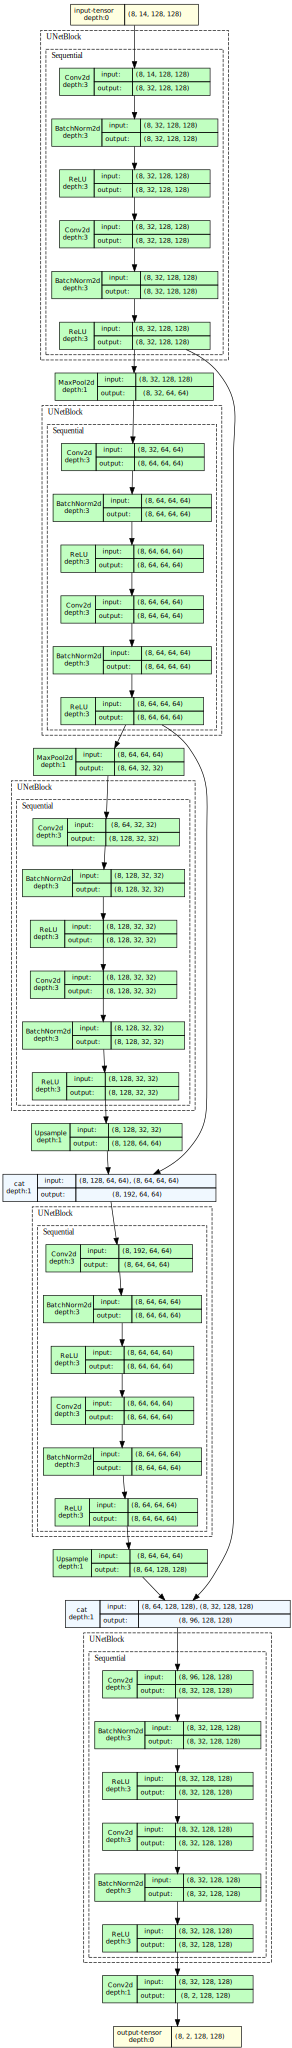

In [ ]:
# Create UNet model and move to device
model = UNet(in_channels=INPUT_CHANNELS, num_classes=NUM_CLASSES).to(device)

checkpoint = torch.load(
    f"{PROJECT_DIR}/models/final/{model_file}",
    map_location=torch.device("cpu") # Load to CPU first
)

# Get the actual model state_dict from the checkpoint, which is nested
pretrained_model_state_dict = checkpoint['model_state_dict']

# Create a new state_dict for the current model instance
model_state_dict = model.state_dict()

# Move the model to the correct device (using 'device' from setup cell)
model = model.to(device) # Use 'device' variable for consistency

# Define INPUT_SIZE from metadata for model summary and graph
INPUT_SIZE = (meta["patch_size"], meta["patch_size"])

# Display model summary
print("UNet Model Summary:")
print("="*60)
summary(model, input_size=(INPUT_CHANNELS, INPUT_SIZE[0], INPUT_SIZE[1]))
print("="*60)
model_graph = draw_graph(model, input_size=(BATCH_SIZE,)+(INPUT_CHANNELS,)+INPUT_SIZE, expand_nested=True, depth=3)
model_graph.visual_graph

In [ ]:
# Freeze parameters of the first downsampling block (early encoder)
for param in model.down_block1.parameters():
    param.requires_grad = False

# Unfreeze parameters of the second downsampling block (later encoder),
# bottleneck, and all upsampling blocks (decoder)
for param in model.down_block2.parameters():
    param.requires_grad = True
for param in model.bottleneck.parameters():
    param.requires_grad = True
for param in model.up_block1.parameters():
    param.requires_grad = True
for param in model.up_block2.parameters():
    param.requires_grad = True
for param in model.output.parameters():
    param.requires_grad = True

print("Parameters freezing/unfreezing applied.")

Parameters freezing/unfreezing applied.


In [ ]:
# Define parameter groups for differential learning rates
# Encoder parameters (unfrozen part)
encoder_params = list(model.down_block2.parameters())
# Decoder parameters (bottleneck, upsampling blocks, and output layer)
decoder_params = list(model.bottleneck.parameters()) + \
                 list(model.up_block1.parameters()) + \
                 list(model.up_block2.parameters()) + \
                 list(model.output.parameters())

optimizer = torch.optim.AdamW(
    [
        {'params': encoder_params, 'lr': LR_ENCODER},
        {'params': decoder_params, 'lr': LR_DECODER}
    ]
)

print(f"Optimizer configured with LR_ENCODER={LR_ENCODER} for encoder_params and LR_DECODER={LR_DECODER} for decoder_params.")

Optimizer configured with LR_ENCODER=1e-05 for encoder_params and LR_DECODER=0.0001 for decoder_params.


Starting training with torchmetrics...
Epoch   1/30 | Loss: 0.4052 | Acc: 0.8212 | IoU: 0.6968 | Val Loss: 0.3022 | Val Acc: 0.8835 | Val IoU: 0.7932


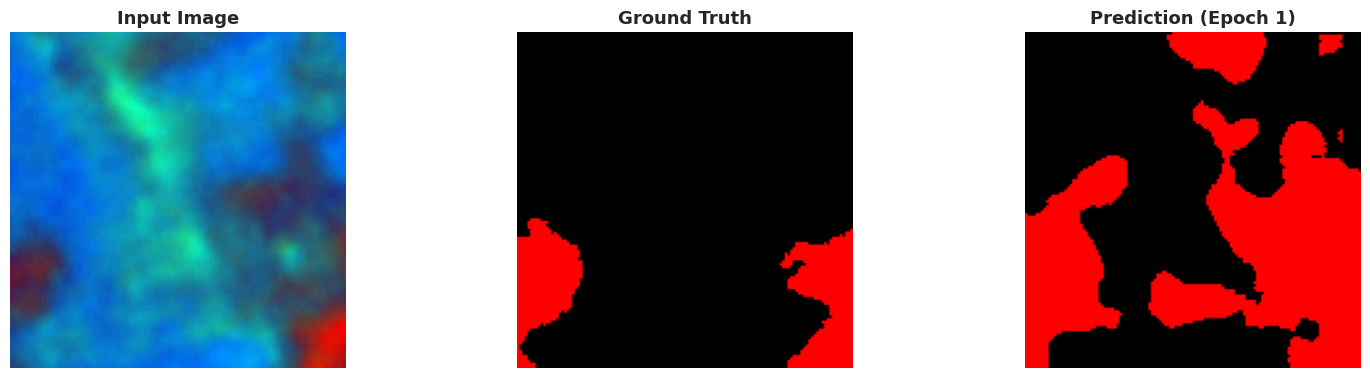

Epoch   2/30 | Loss: 0.3765 | Acc: 0.8340 | IoU: 0.7154 | Val Loss: 0.3237 | Val Acc: 0.8653 | Val IoU: 0.7672
Epoch   3/30 | Loss: 0.3661 | Acc: 0.8395 | IoU: 0.7236 | Val Loss: 0.2815 | Val Acc: 0.8888 | Val IoU: 0.8022
Epoch   4/30 | Loss: 0.3590 | Acc: 0.8444 | IoU: 0.7308 | Val Loss: 0.2649 | Val Acc: 0.8949 | Val IoU: 0.8120
Epoch   5/30 | Loss: 0.3513 | Acc: 0.8502 | IoU: 0.7395 | Val Loss: 0.2773 | Val Acc: 0.8925 | Val IoU: 0.8087
Epoch   6/30 | Loss: 0.3433 | Acc: 0.8521 | IoU: 0.7424 | Val Loss: 0.2735 | Val Acc: 0.8913 | Val IoU: 0.8071


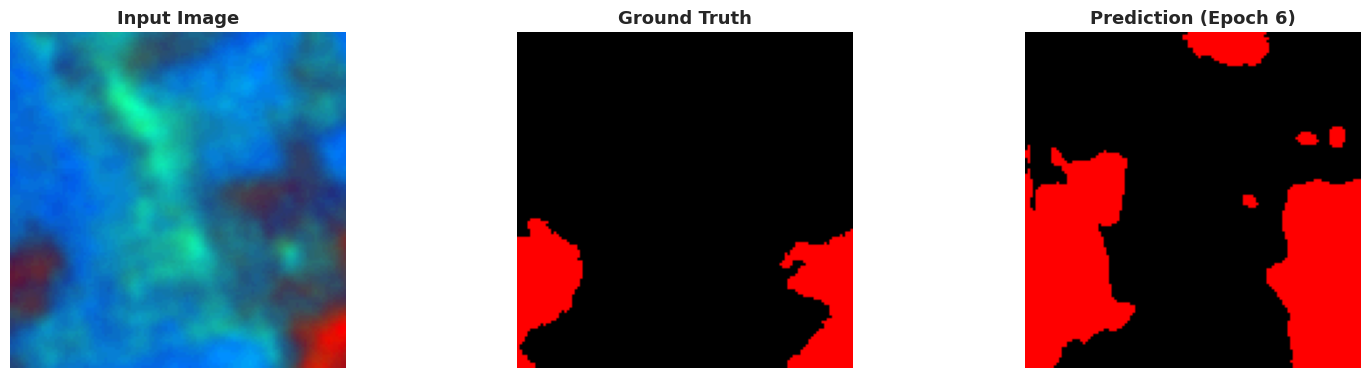

Epoch   7/30 | Loss: 0.3384 | Acc: 0.8535 | IoU: 0.7446 | Val Loss: 0.2499 | Val Acc: 0.8999 | Val IoU: 0.8201
Epoch   8/30 | Loss: 0.3329 | Acc: 0.8586 | IoU: 0.7522 | Val Loss: 0.2441 | Val Acc: 0.9057 | Val IoU: 0.8285
Epoch   9/30 | Loss: 0.3133 | Acc: 0.8665 | IoU: 0.7645 | Val Loss: 0.2464 | Val Acc: 0.9010 | Val IoU: 0.8223
Epoch  10/30 | Loss: 0.3025 | Acc: 0.8734 | IoU: 0.7753 | Val Loss: 0.2365 | Val Acc: 0.9080 | Val IoU: 0.8325
Epoch  11/30 | Loss: 0.3047 | Acc: 0.8716 | IoU: 0.7725 | Val Loss: 0.2516 | Val Acc: 0.9010 | Val IoU: 0.8218


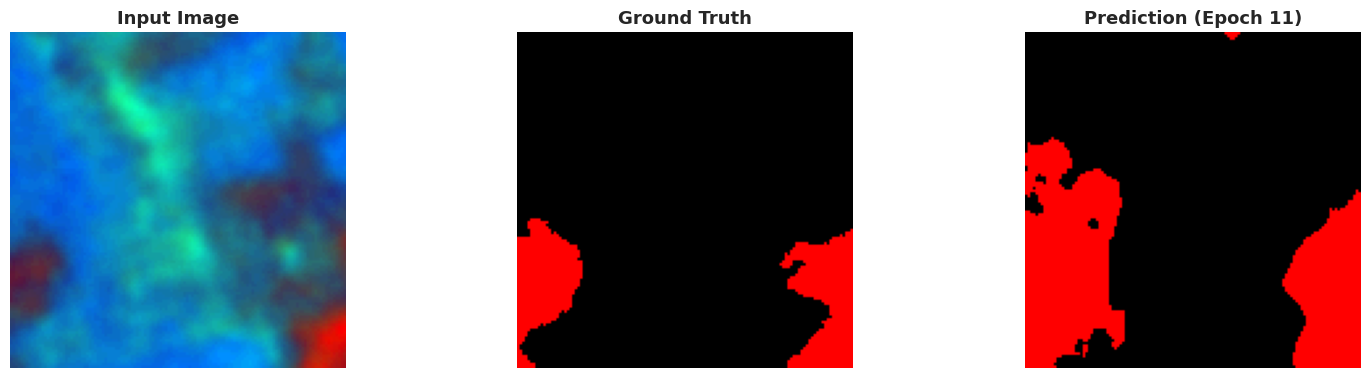

Epoch  12/30 | Loss: 0.3092 | Acc: 0.8675 | IoU: 0.7661 | Val Loss: 0.2532 | Val Acc: 0.8954 | Val IoU: 0.8130
Epoch  13/30 | Loss: 0.2876 | Acc: 0.8791 | IoU: 0.7844 | Val Loss: 0.2492 | Val Acc: 0.8951 | Val IoU: 0.8135
Epoch  14/30 | Loss: 0.3006 | Acc: 0.8740 | IoU: 0.7762 | Val Loss: 0.2506 | Val Acc: 0.9002 | Val IoU: 0.8203
Epoch  15/30 | Loss: 0.2949 | Acc: 0.8763 | IoU: 0.7799 | Val Loss: 0.2241 | Val Acc: 0.9076 | Val IoU: 0.8328
Epoch  16/30 | Loss: 0.2863 | Acc: 0.8810 | IoU: 0.7874 | Val Loss: 0.2440 | Val Acc: 0.9060 | Val IoU: 0.8307


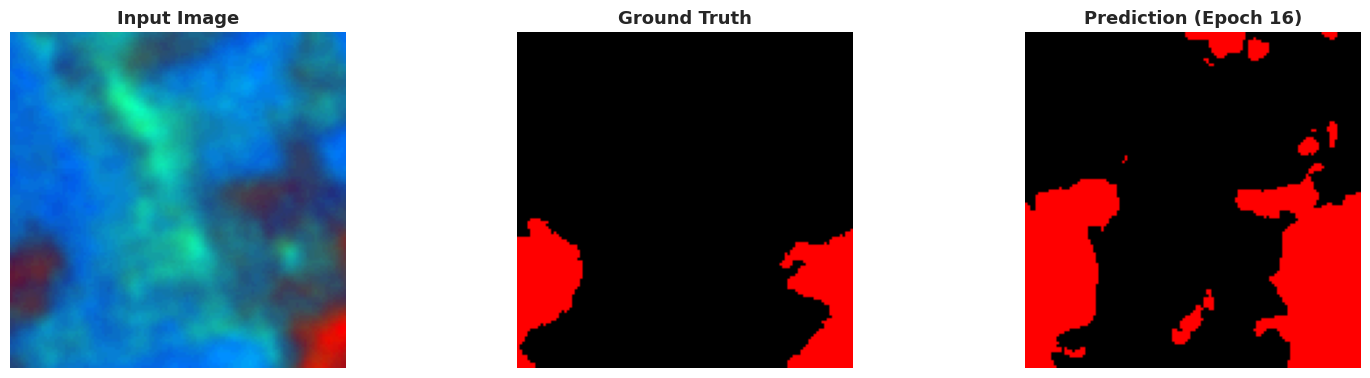

Epoch  17/30 | Loss: 0.2806 | Acc: 0.8823 | IoU: 0.7894 | Val Loss: 0.2245 | Val Acc: 0.9081 | Val IoU: 0.8330
Epoch  18/30 | Loss: 0.2838 | Acc: 0.8794 | IoU: 0.7848 | Val Loss: 0.2335 | Val Acc: 0.9033 | Val IoU: 0.8264
Epoch  19/30 | Loss: 0.2958 | Acc: 0.8756 | IoU: 0.7788 | Val Loss: 0.2635 | Val Acc: 0.8869 | Val IoU: 0.8003
Epoch  20/30 | Loss: 0.2818 | Acc: 0.8836 | IoU: 0.7915 | Val Loss: 0.2183 | Val Acc: 0.9136 | Val IoU: 0.8429
Epoch  21/30 | Loss: 0.2895 | Acc: 0.8785 | IoU: 0.7833 | Val Loss: 0.2363 | Val Acc: 0.9058 | Val IoU: 0.8270


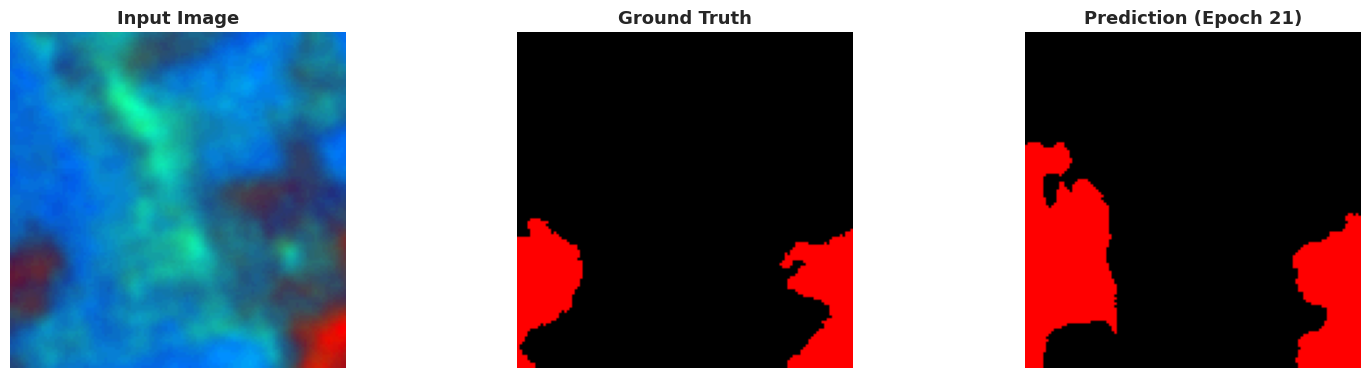

Epoch  22/30 | Loss: 0.2783 | Acc: 0.8832 | IoU: 0.7909 | Val Loss: 0.2326 | Val Acc: 0.9071 | Val IoU: 0.8323
Epoch  23/30 | Loss: 0.2845 | Acc: 0.8799 | IoU: 0.7857 | Val Loss: 0.2225 | Val Acc: 0.9108 | Val IoU: 0.8372
Epoch  24/30 | Loss: 0.2724 | Acc: 0.8869 | IoU: 0.7968 | Val Loss: 0.2020 | Val Acc: 0.9193 | Val IoU: 0.8522
Epoch  25/30 | Loss: 0.2774 | Acc: 0.8834 | IoU: 0.7912 | Val Loss: 0.2232 | Val Acc: 0.9115 | Val IoU: 0.8394
Epoch  26/30 | Loss: 0.2810 | Acc: 0.8804 | IoU: 0.7864 | Val Loss: 0.2416 | Val Acc: 0.9019 | Val IoU: 0.8243


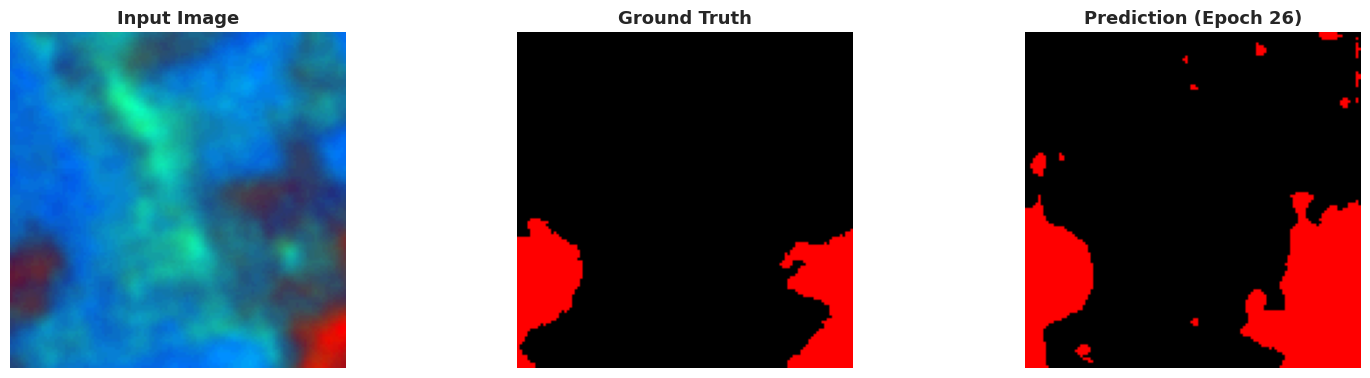

Epoch  27/30 | Loss: 0.2662 | Acc: 0.8905 | IoU: 0.8027 | Val Loss: 0.2256 | Val Acc: 0.9098 | Val IoU: 0.8361
Epoch  28/30 | Loss: 0.2607 | Acc: 0.8911 | IoU: 0.8036 | Val Loss: 0.2196 | Val Acc: 0.9130 | Val IoU: 0.8422
Epoch  29/30 | Loss: 0.2507 | Acc: 0.8960 | IoU: 0.8116 | Val Loss: 0.2158 | Val Acc: 0.9079 | Val IoU: 0.8325

Early stopping triggered at epoch 29
Training finished!
Restored best model from epoch 24 (Val Mean IoU: 0.8522)

Final validation Mean IoU: 85.22%
CPU times: user 1min 56s, sys: 28.7 s, total: 2min 24s
Wall time: 5min 35s


In [ ]:
%%time
# Setup TensorBoard writer
# experiment_name = f"unet_finetuning_{PATCHES_FOLDER_NAME}_01"
writer = SummaryWriter(f"./{logs_dir}/{experiment_name}")
Path(f"models/checkpoints/{experiment_name}").mkdir(parents=True, exist_ok=True)
Path(f"experiments/{experiment_name}").mkdir(parents=True, exist_ok=True)


# Train the model
model, history = train_segmentation_model(
    model=model,
    train_loader=train_loader,
    val_dataset = val_dataset,
    val_loader=val_loader,
    meta=meta,
    epochs=EPOCHS,
    learning_rate=LR,
    patience=PATIENCE,
    num_classes=NUM_CLASSES,
    device=device,
    writer=writer,
    experiment_name=experiment_name,
    visualize_every=5
)

# Display final validation IoU
final_val_iou = round(max(history['val_mean_iou']) * 100, 2)
print(f'\nFinal validation Mean IoU: {final_val_iou}%')

## 📈 **Plot Training History**

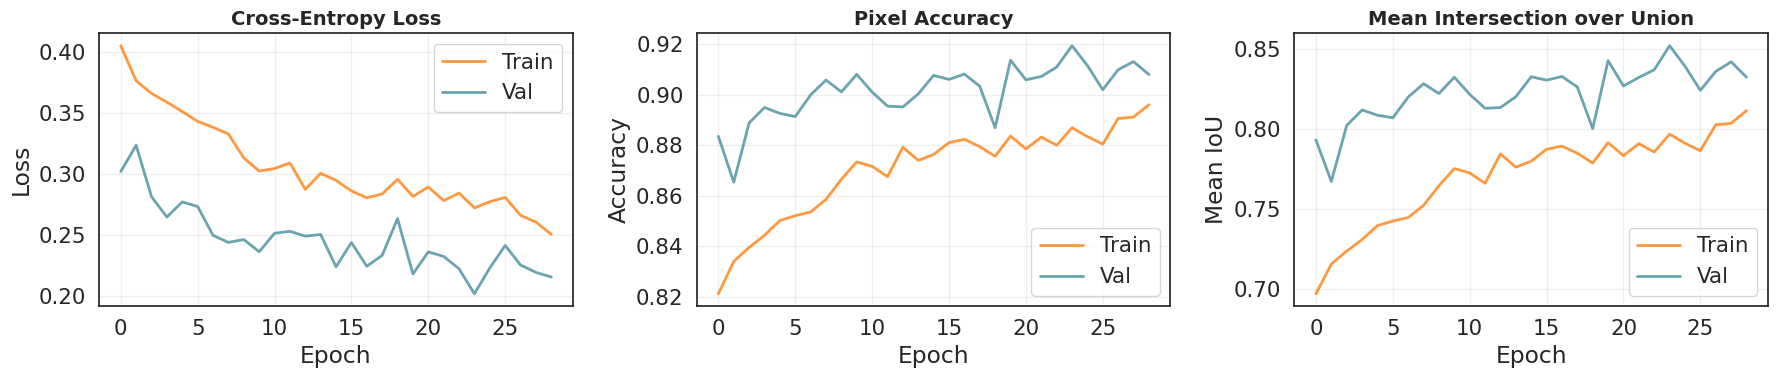

In [ ]:
# Plot training curves for loss, accuracy, and Mean IoU
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Loss plot
axes[0].plot(history['loss'], label='Train', alpha=0.8, color='#ff7f0e', linewidth=2)
axes[0].plot(history['val_loss'], label='Val', alpha=0.9, color='#5a9aa5', linewidth=2)
axes[0].set_title('Cross-Entropy Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy plot
axes[1].plot(history['accuracy'], label='Train', alpha=0.8, color='#ff7f0e', linewidth=2)
axes[1].plot(history['val_accuracy'], label='Val', alpha=0.9, color='#5a9aa5', linewidth=2)
axes[1].set_title('Pixel Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Mean IoU plot
axes[2].plot(history['mean_iou'], label='Train', alpha=0.8, color='#ff7f0e', linewidth=2)
axes[2].plot(history['val_mean_iou'], label='Val', alpha=0.9, color='#5a9aa5', linewidth=2)
axes[2].set_title('Mean Intersection over Union', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Mean IoU')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()

plt.savefig(f"experiments/{experiment_name}/training_curves.png")
plt.show()

In [ ]:
print("\nCreating test dataset...")

test_dataset = NPYSegmentationDataset(
    root         = OUT_DIR,
    split        = "test",
    augmentation = False
)

test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = True
)

print(f"Test dataset size: {len(test_dataset)}")
print(f"Test batches: {len(test_loader)}")


Creating test dataset...
Test dataset size: 600
Test batches: 75


In [ ]:
best_model_path = f"models/final/{experiment_name}_best.pt"

# Load the checkpoint dictionary
checkpoint = torch.load(best_model_path, map_location=torch.device('cpu'))

# Extract the model's state_dict from the checkpoint
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"\nLoaded best model from: {best_model_path}")


Loaded best model from: models/final/finetuning_dataset_patches_PS_14_bands_excluding_blue_01_best.pt


In [ ]:
# Evaluate on test set using torchmetrics
print("\nEvaluating UNet from scratch on test set...")

# Setup metrics
criterion = nn.CrossEntropyLoss(ignore_index=255)
test_iou_metric = torchmetrics.JaccardIndex(
    task='multiclass',
    num_classes=NUM_CLASSES,
    ignore_index=255,
    average='weighted'
).to(device)

test_iou_per_class = torchmetrics.JaccardIndex(
    task='multiclass',
    num_classes=NUM_CLASSES,
    ignore_index=255,
    average='none'
).to(device)

test_loss = 0.0
test_correct = 0
test_total = 0

model.eval()
with torch.no_grad():
    for batch_images, batch_labels in test_loader:
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)

        # Forward pass
        outputs = model(batch_images)
        loss = criterion(outputs, batch_labels)

        # Accumulate metrics
        test_loss += loss.item() * batch_images.size(0)
        preds = outputs.argmax(dim=1)
        test_correct += (preds == batch_labels).sum().item()
        test_total += batch_labels.numel()

        # Update IoU metrics
        test_iou_metric.update(preds, batch_labels)
        test_iou_per_class.update(preds, batch_labels)

# Compute final test metrics
test_loss = test_loss / len(test_loader.dataset)
test_acc = test_correct / test_total
test_mean_iou = test_iou_metric.compute().item()
test_iou_classes = test_iou_per_class.compute()

print("\n" + "="*60)
print("TEST RESULTS - UNet from Scratch")
print("="*60)
print(f"Test Loss:        {test_loss:.4f}")
print(f"Test Accuracy:    {test_acc:.4f}")
print(f"Test Mean IoU:    {test_mean_iou:.4f}")
print("="*60)

# Save test results to a file
results_filename = f"experiments/{experiment_name}/test_results.txt"
with open(results_filename, 'w') as f:
    f.write(f"Test Loss: {test_loss:.4f}\n")
    f.write(f"Test Accuracy: {test_acc:.4f}\n")
    f.write(f"Test Mean IoU: {test_mean_iou:.4f}\n")
print(f"Test results saved to {results_filename}")


Evaluating UNet from scratch on test set...

TEST RESULTS - UNet from Scratch
Test Loss:        0.2565
Test Accuracy:    0.8794
Test Mean IoU:    0.8048
Test results saved to experiments/finetuning_dataset_patches_PS_14_bands_excluding_blue_01/test_results.txt


In [ ]:
class_names = {
    0: 'Unburned',
    1: 'Burned',
    255: 'Unmapped',
}

# Display per-class IoU using torchmetrics results
print("\nPer-class IoU Analysis (using torchmetrics):")
print("="*60)

per_class_iou = []
results_filename = f"experiments/{experiment_name}/test_results.txt"
with open(results_filename, 'a') as f: # Open in append mode
    f.write("\nPer-class IoU Analysis:\n")
    for c in range(NUM_CLASSES):
        if c == 255:  # Skip background
            continue
        iou_value = test_iou_classes[c].item()
        class_name = class_names.get(c, f'Class {c}')
        per_class_iou.append((class_name, iou_value))
        print(f"{class_name:20s}: {iou_value:.4f}")
        f.write(f"{class_name:20s}: {iou_value:.4f}\n")

print("="*60)
print(f"Per-class IoU results appended to {results_filename}")


Per-class IoU Analysis (using torchmetrics):
Unburned            : 0.8064
Burned              : 0.8031
Per-class IoU results appended to experiments/finetuning_dataset_patches_PS_14_bands_excluding_blue_01/test_results.txt


## 👁️ **Visualise Test Predictions**

Visualising test predictions:


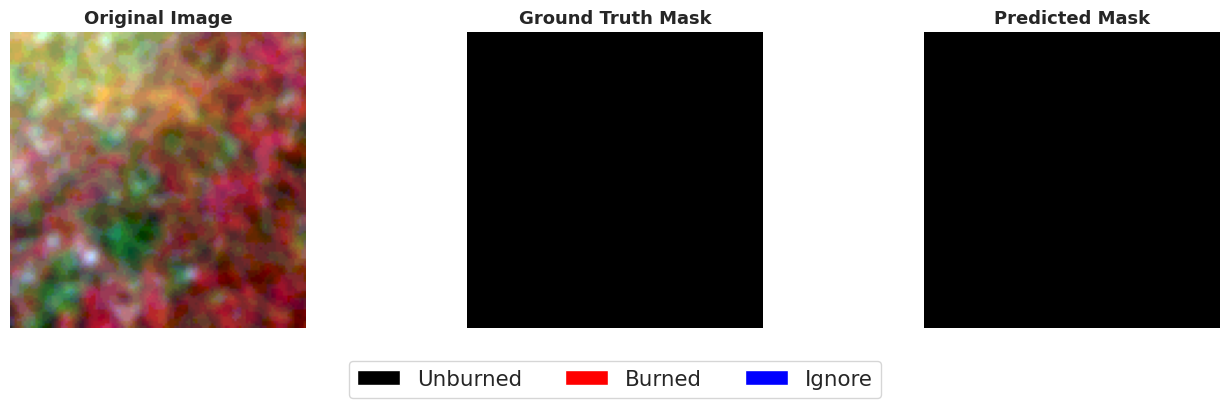

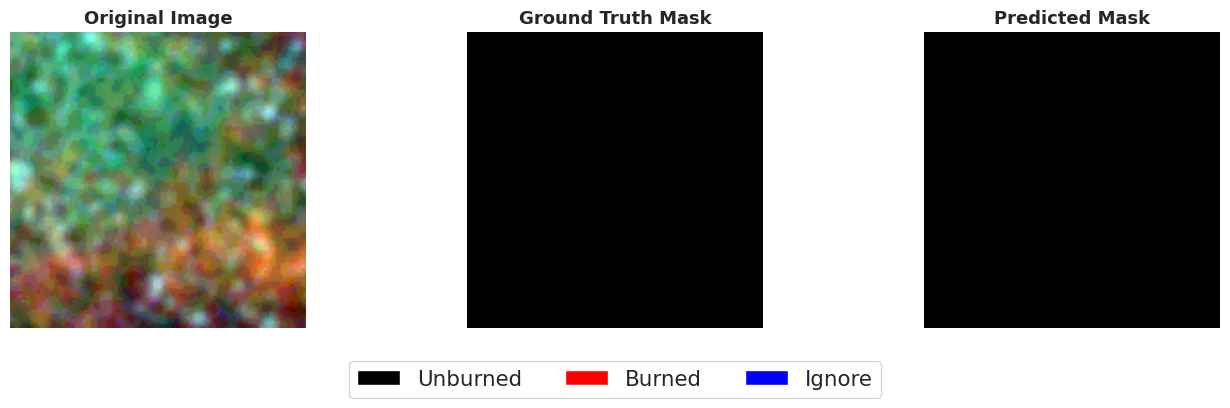

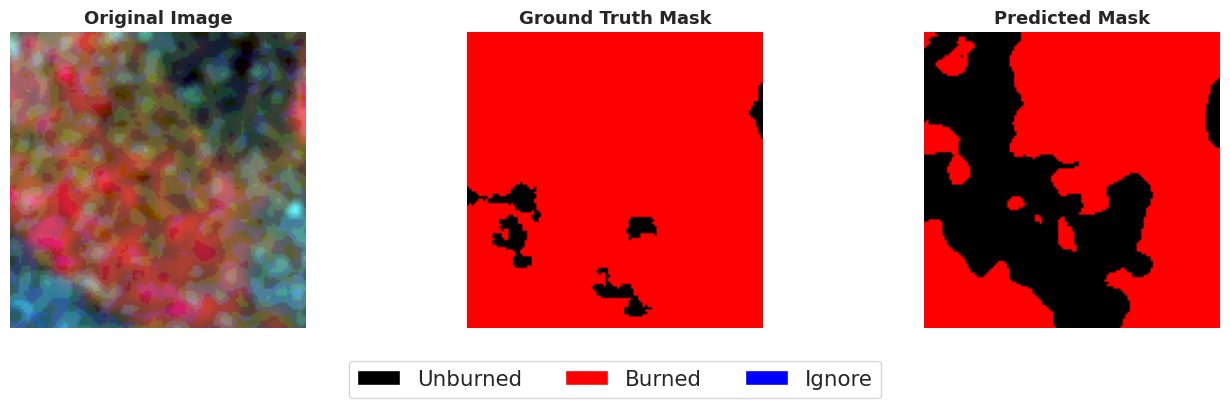

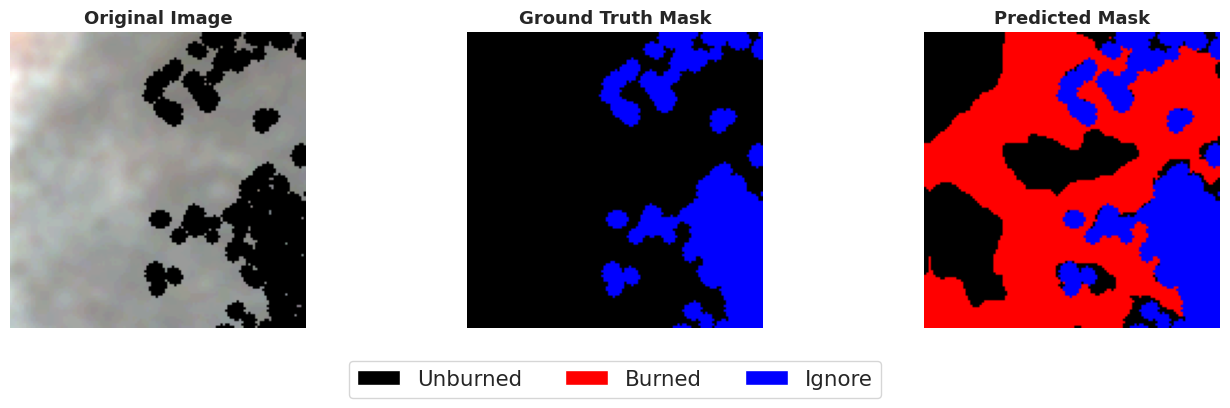

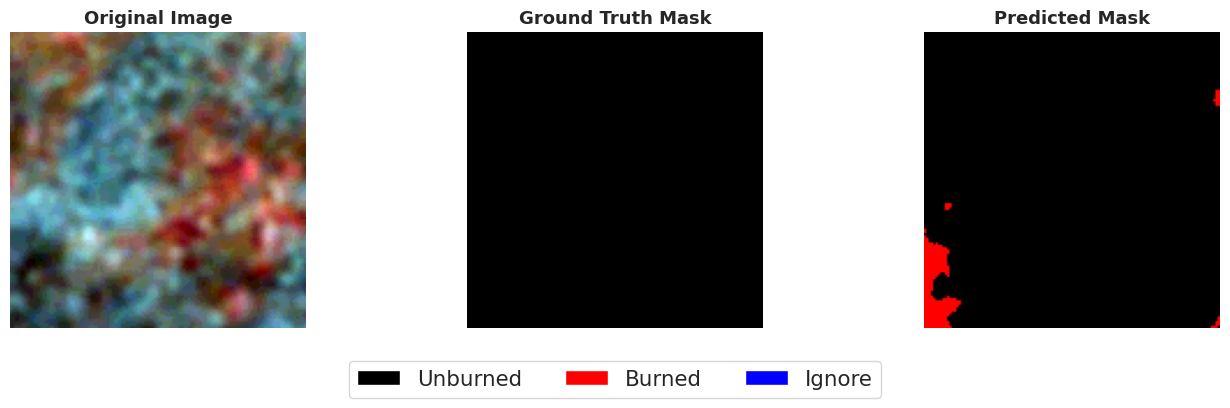

In [ ]:
print("Visualising test predictions:")
plot_triptychs_from_loader(test_loader, model, num_samples=5, device=device, experiment_name=experiment_name)

## 👁️ **Visualise Pre-Argmax Output Maps**

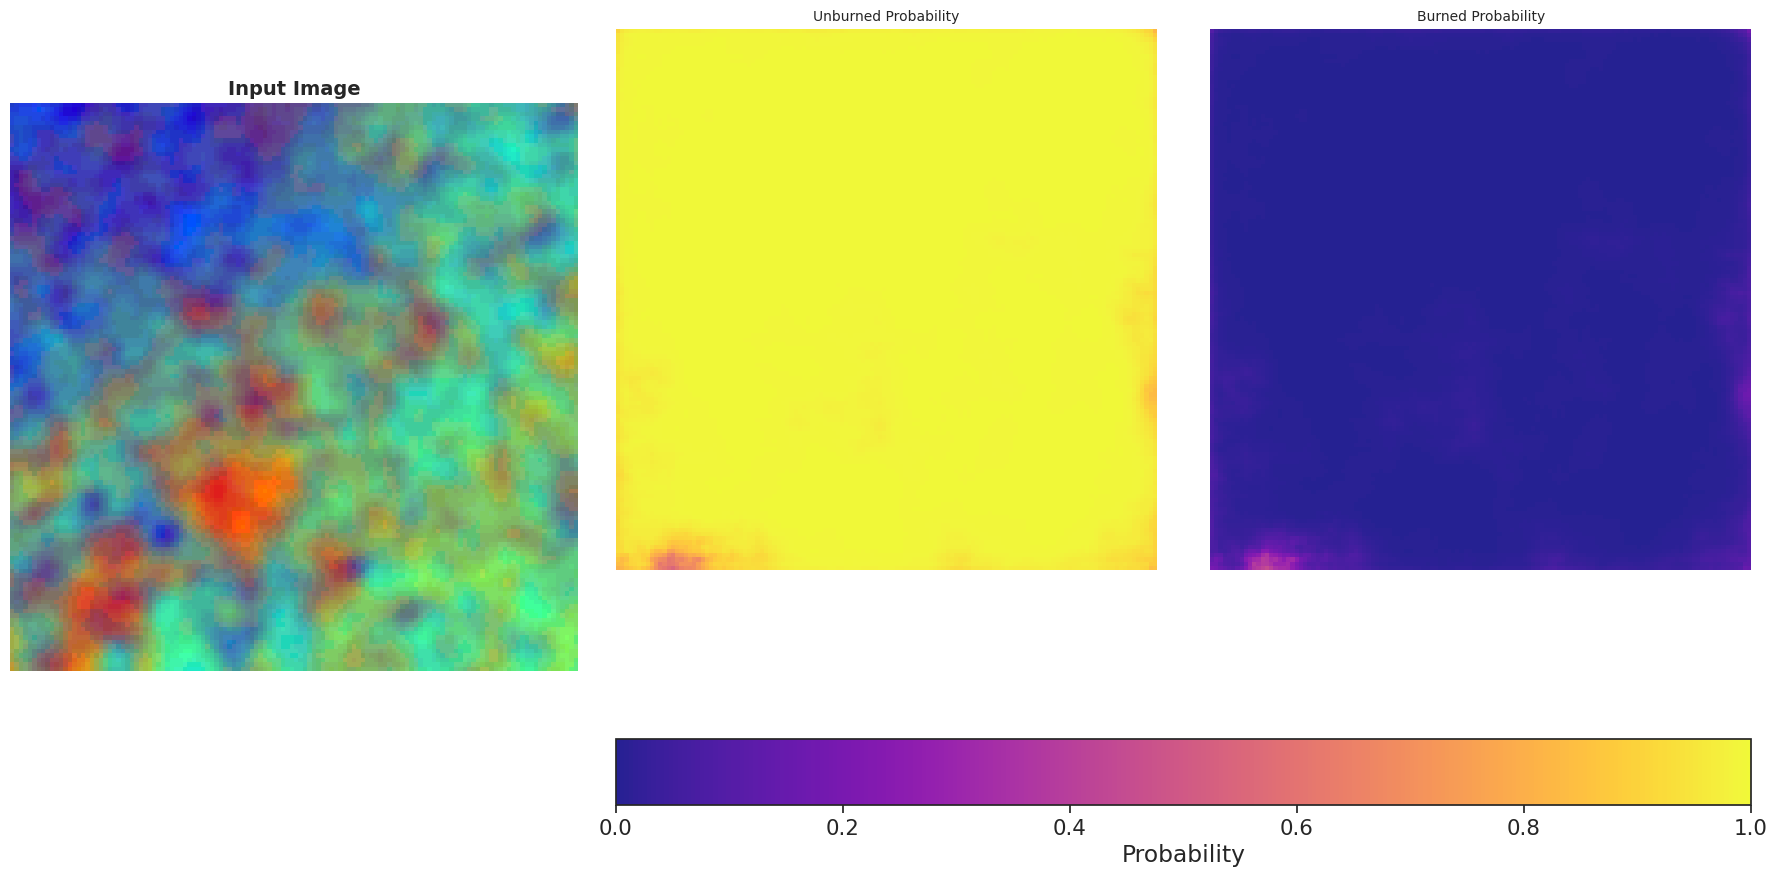

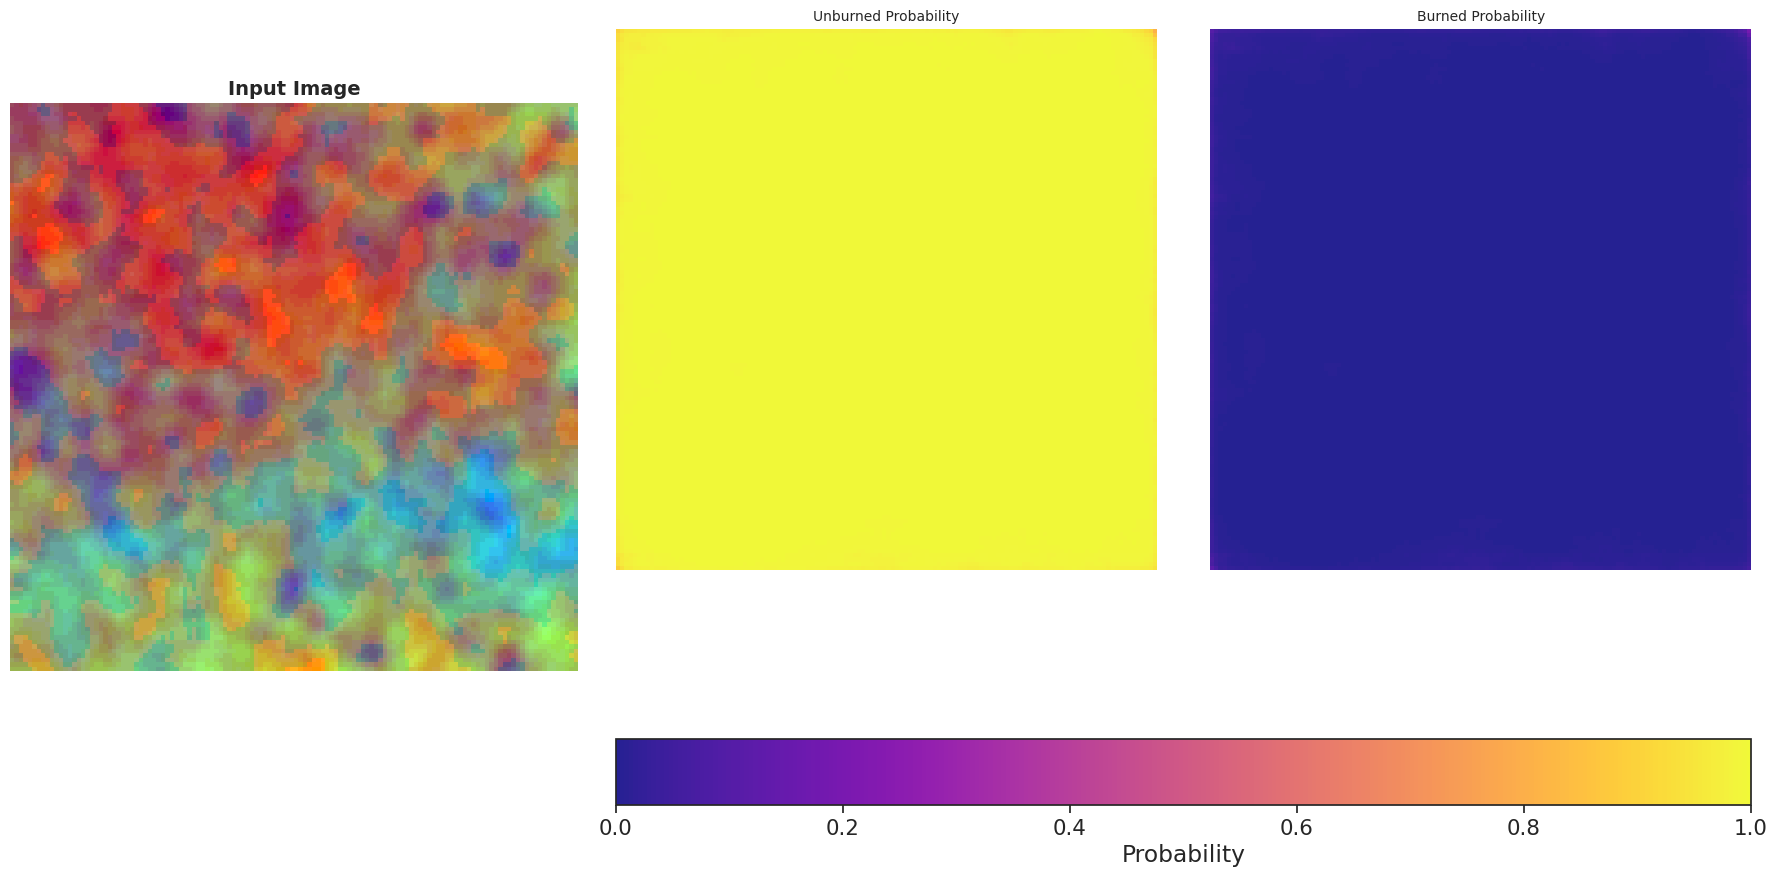

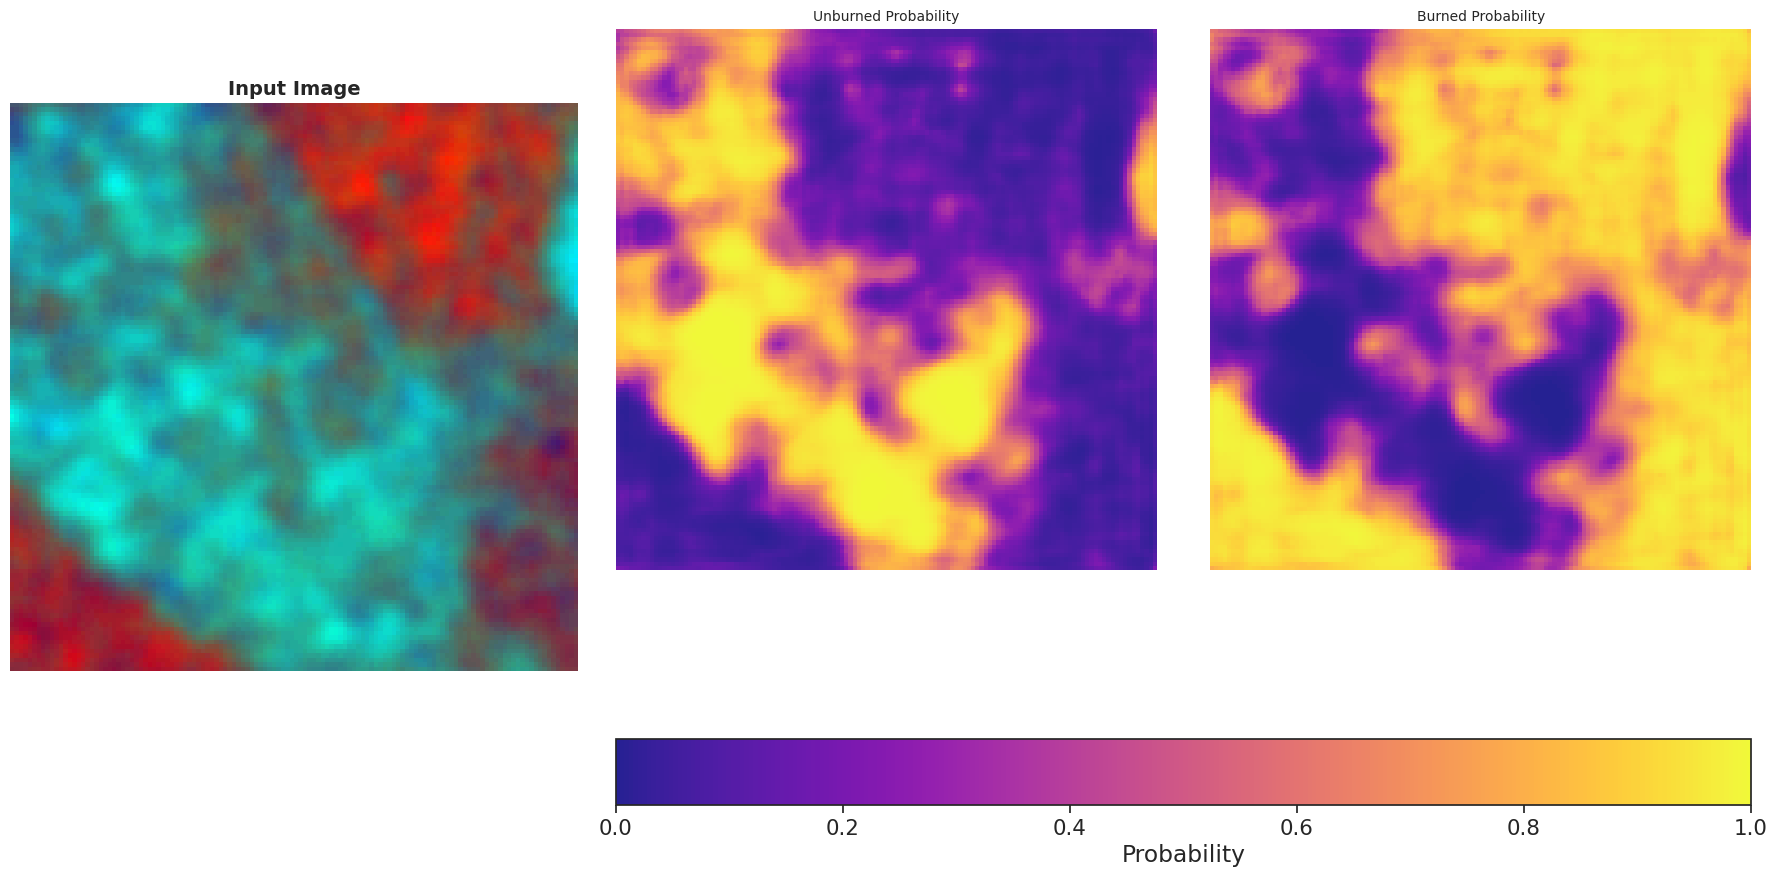

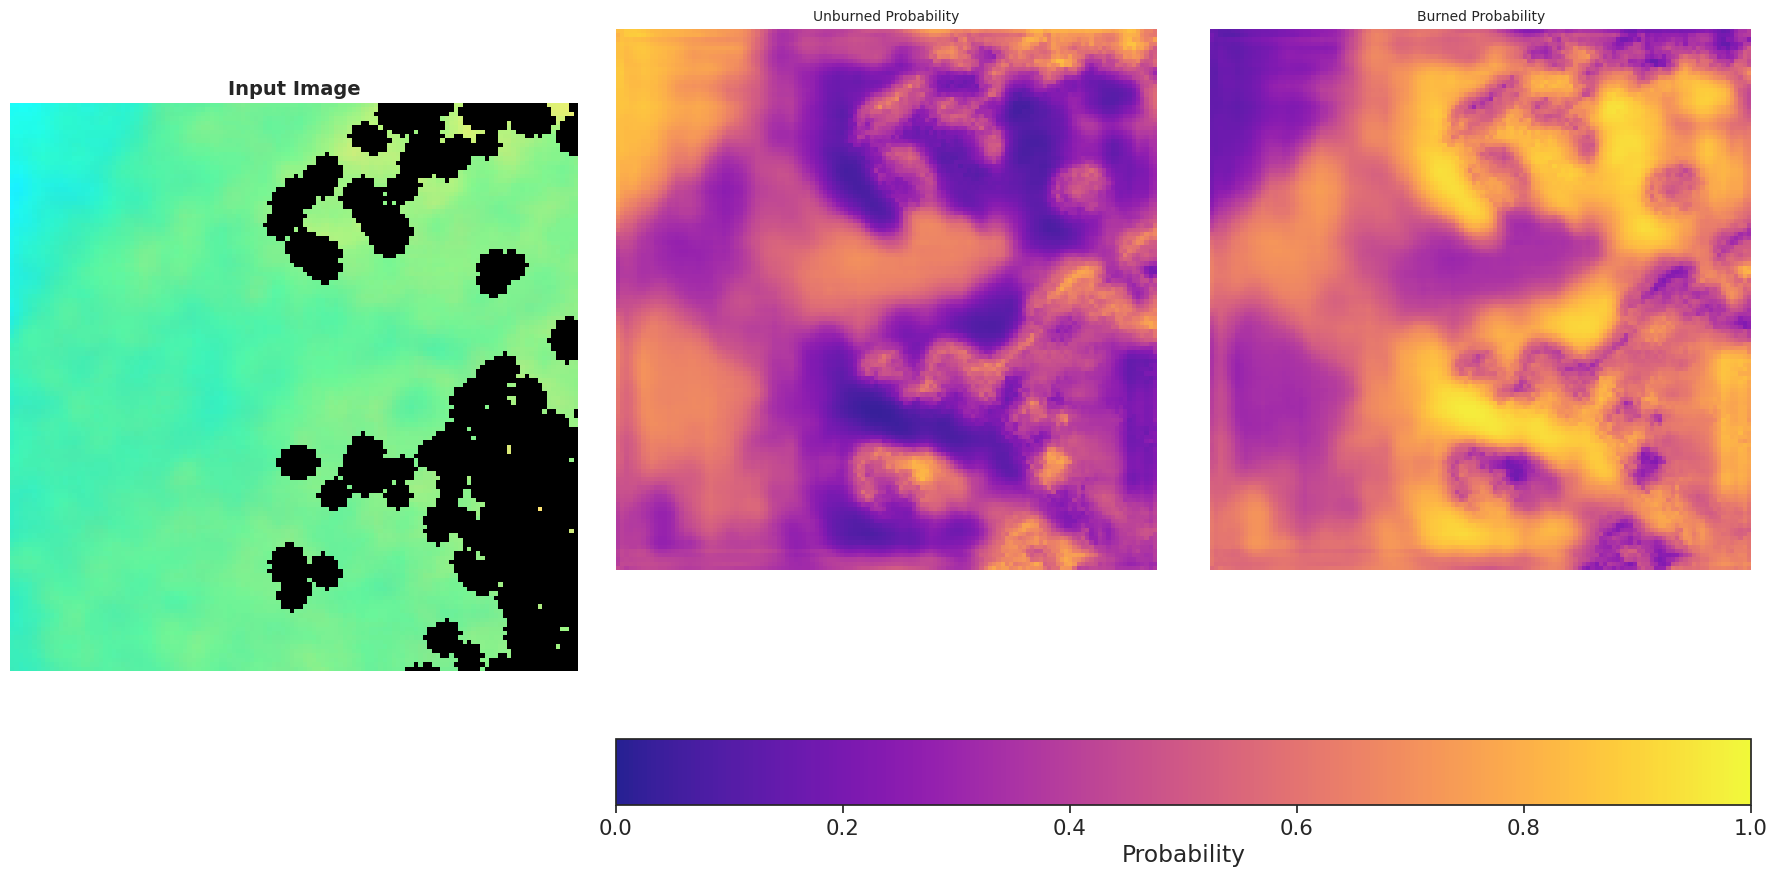

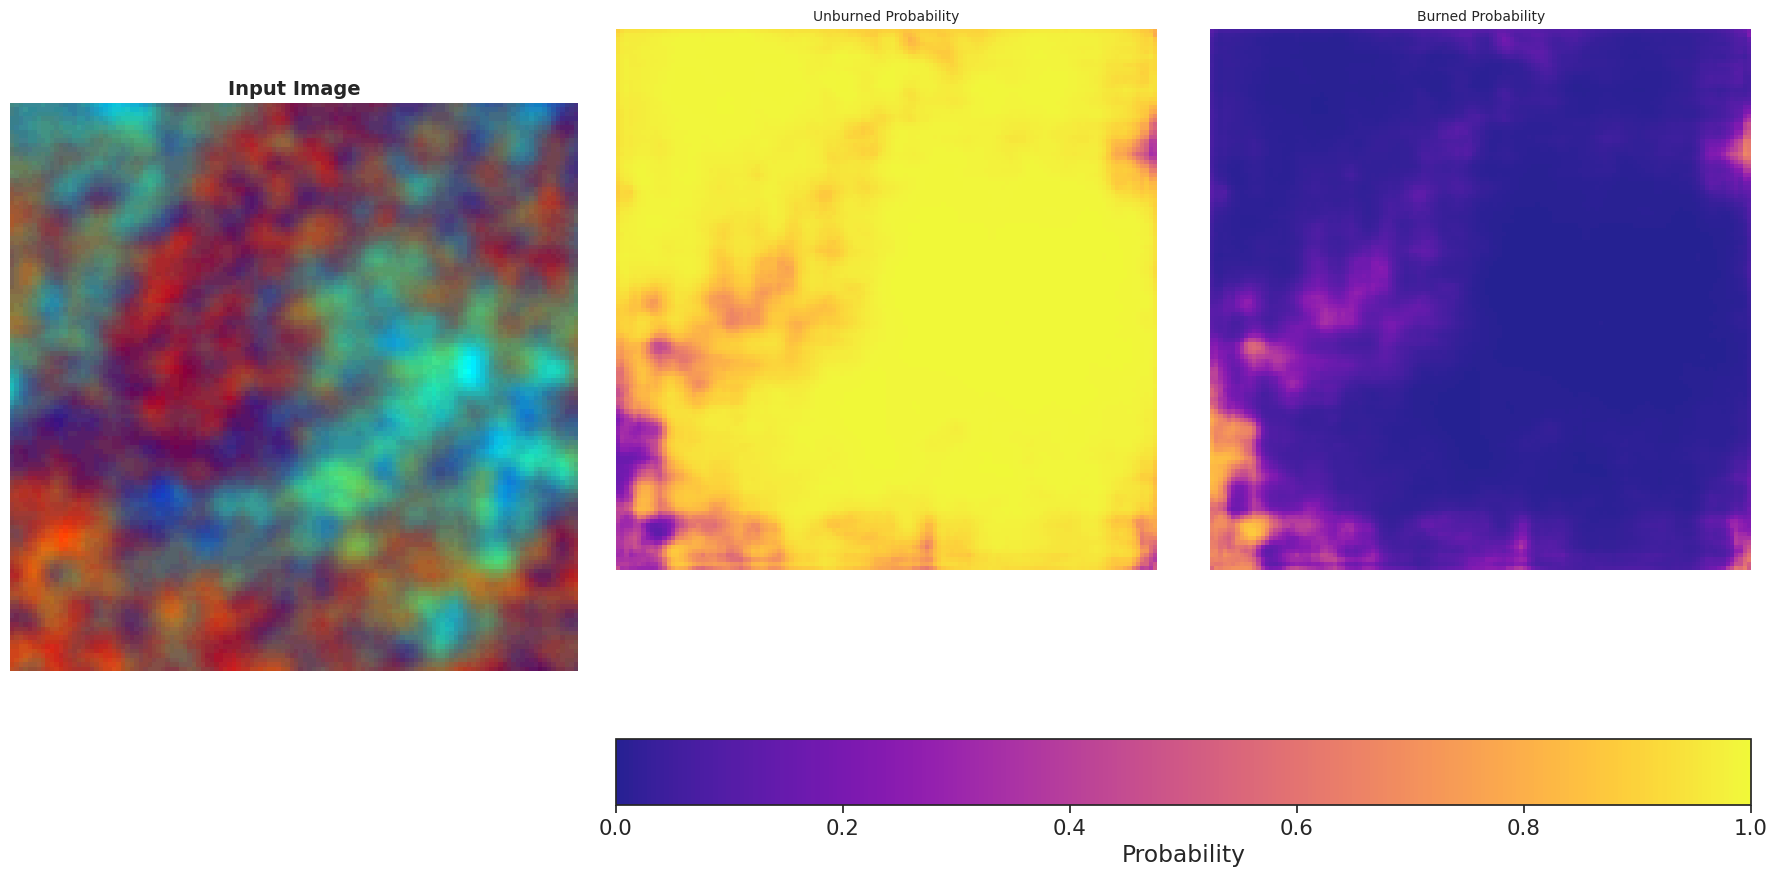

In [ ]:
plot_layer_outputs_from_loader(test_loader, model, num_samples=5, device=device, experiment_name=experiment_name)

## 📚 Resources
This notebook builds upon the foundational work presented in previous notebooks. For a comprehensive understanding of the entire process, including patch creation and merging, please refer to the following:

- **Patch_creation notebook**: Details on how image patches are generated from raw multispectral satellite images.
- **Merging_patches notebook**: Explains the process of combining and preparing these patches for model training.

These resources provide the necessary context for the data used in this fine-tuning notebook.

##### Contributors:
- **Evgenii Miasnikov**: evgenii.miasnikov@mail.polimi.it
- **Ayman Mutasim Alfadul Abdelgadir**: aymanmutasim@mail.polimi.it
- **Eugenio Lomurno**: eugenio.lomurno@polimi.it
- **Alberto Archetti**: alberto.archetti@polimi.it
- **Roberto Basla**: roberto.basla@polimi.it
- **Carlo Sgaravatti**: carlo.sgaravatti@polimi.it

```
   Original code:
   Copyright 2025 Eugenio Lomurno, Alberto Archetti, Roberto Basla, Carlo Sgaravatti

   Modifications:
   Copyright 2026 Evgenii Miasnikov, Ayman Mutasim Alfadul Abdelgadir

   Licensed under the Apache License, Version 2.0 (the "License");
   you may not use this file except in compliance with the License.
   You may obtain a copy of the License at

       https://www.apache.org/licenses/LICENSE-2.0

   Unless required by applicable law or agreed to in writing, software
   distributed under the License is distributed on an "AS IS" BASIS,
   WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
   See the License for the specific language governing permissions and
   limitations under the License.
```